Please upload your Employee Salary CSV or ZIP file


Saving archive.zip to archive.zip

Uploaded file: archive.zip

ZIP file detected. Extracting...
CSV file found: extracted_data/Employee_Salary_Dataset.csv

================ DATASET LOADED ================

First 5 Rows:
   ID  Experience_Years  Age  Gender  Salary
0   1                 5   28  Female  250000
1   2                 1   21    Male   50000
2   3                 3   23  Female  170000
3   4                 2   22    Male   25000
4   5                 1   17    Male   10000

Dataset Shape:
(35, 5)

Column Names:
['ID', 'Experience_Years', 'Age', 'Gender', 'Salary']

================ DATASET INFORMATION ================

Data Types:
ID                   int64
Experience_Years     int64
Age                  int64
Gender              object
Salary               int64
dtype: object

Statistical Summary:
              ID  Experience_Years        Age        Salary
count  35.000000          35.00000  35.000000  3.500000e+01
mean   18.000000           9.20000  35.485714  2.059147e+0

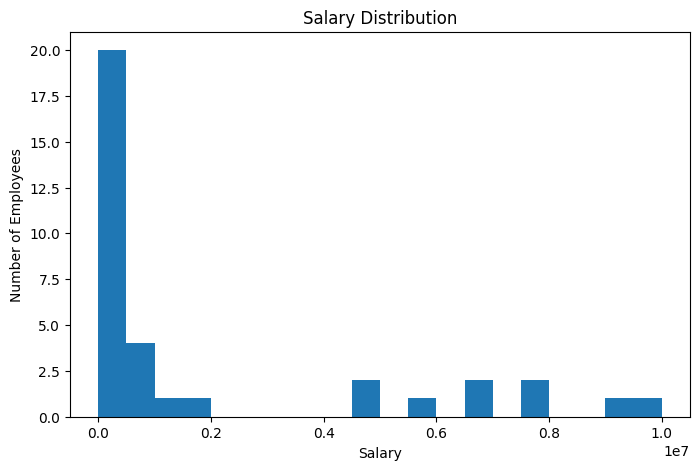

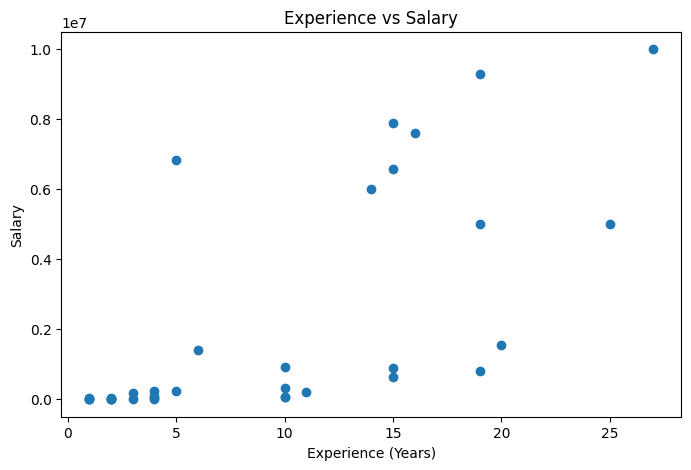

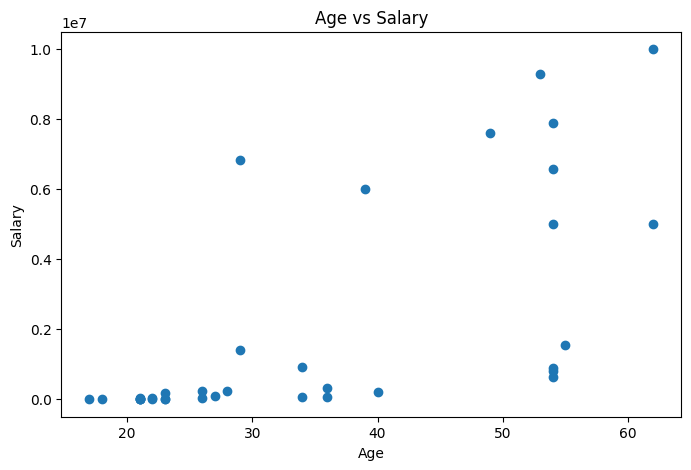


================ TRAIN TEST SPLIT ================
Training data: (28, 2)
Testing data: (7, 2)

================ MODEL TRAINING ================
Linear Regression model trained successfully!

Model Coefficients:
[  3196.49826178 278648.50498449]

Model Intercept:
-416533.646381957

================ ACTUAL VS PREDICTED SALARY ================
   Actual Salary  Predicted Salary
0           3000     -8.034817e+04
1         220100      2.776460e+06
2           8900      7.715798e+05
3          25000      7.811693e+05
4          87000      7.843658e+05
5           6100      2.078898e+05
6         330000      2.485025e+06

================ MODEL PERFORMANCE ================
Mean Absolute Error (MAE): 1030391.17
Root Mean Squared Error (RMSE): 1355758.49
R² Score: -128.1995


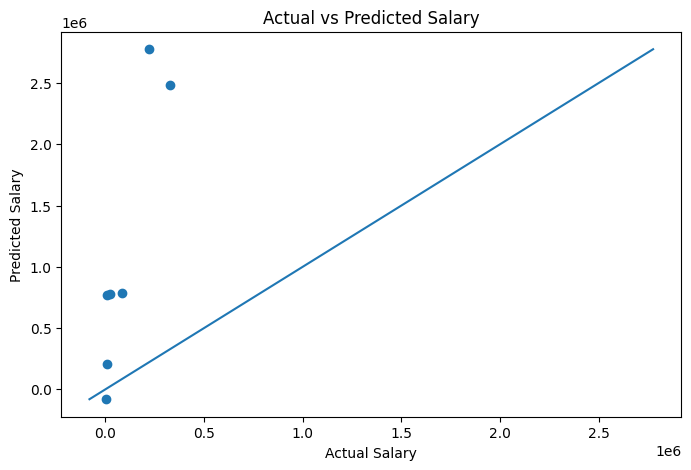


================ NEW EMPLOYEE PREDICTION ================
Age: 30
Experience: 5 Years
Predicted Salary: 1072603.83

Prediction results saved as:
Salary_Prediction_Results.csv

       EMPLOYEE SALARY PREDICTION ANALYSIS
Algorithm : Linear Regression
Target    : Salary
Features  : Age, Experience_Years
Training  : 80%
Testing   : 20%

Model Performance:
MAE  : 1030391.17
RMSE : 1355758.49
R²   : -128.1995

Analysis Completed Successfully!


In [1]:
# ============================================================
# EMPLOYEE SALARY PREDICTION ANALYSIS
# USING LINEAR REGRESSION
# ============================================================

# 1. IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import glob

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ============================================================
# 2. UPLOAD FILE
# ============================================================

print("Please upload your Employee Salary CSV or ZIP file")

uploaded = files.upload()

uploaded_file = list(uploaded.keys())[0]

print("\nUploaded file:", uploaded_file)


# ============================================================
# 3. FIND CSV FILE
# ============================================================

if uploaded_file.lower().endswith(".zip"):

    print("\nZIP file detected. Extracting...")

    with zipfile.ZipFile(uploaded_file, "r") as zip_ref:
        zip_ref.extractall("extracted_data")

    csv_files = glob.glob(
        "extracted_data/**/*.csv",
        recursive=True
    )

    if len(csv_files) == 0:
        raise FileNotFoundError(
            "No CSV file found inside the ZIP file."
        )

    csv_file = csv_files[0]

    print("CSV file found:", csv_file)

elif uploaded_file.lower().endswith(".csv"):

    csv_file = uploaded_file

else:

    raise ValueError(
        "Please upload a CSV or ZIP file."
    )


# ============================================================
# 4. LOAD DATASET
# ============================================================

df = pd.read_csv(csv_file)

print("\n================ DATASET LOADED ================")

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())


# ============================================================
# 5. DATASET INFORMATION
# ============================================================

print("\n================ DATASET INFORMATION ================")

print("\nData Types:")
print(df.dtypes)

print("\nStatistical Summary:")
print(df.describe())


# ============================================================
# 6. CHECK MISSING VALUES
# ============================================================

print("\n================ MISSING VALUES ================")

print(df.isnull().sum())

# Remove rows with missing values
df = df.dropna()

print("\nDataset after removing missing values:")
print(df.shape)


# ============================================================
# 7. CHECK REQUIRED COLUMNS
# ============================================================

print("\n================ CHECKING COLUMNS ================")

print(df.columns.tolist())

required_columns = [
    "Age",
    "Experience_Years",
    "Salary"
]

for column in required_columns:

    if column not in df.columns:

        raise ValueError(
            "Column '" + column + "' was not found in the dataset."
        )

print("\nRequired columns found successfully!")


# ============================================================
# 8. SELECT FEATURES AND TARGET
# ============================================================

# Features used for prediction
X = df[
    [
        "Age",
        "Experience_Years"
    ]
]

# Target variable
y = df["Salary"]

print("\n================ FEATURES AND TARGET ================")

print("\nInput Features:")
print(X.head())

print("\nTarget Salary:")
print(y.head())


# ============================================================
# 9. SALARY DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(
    df["Salary"],
    bins=20
)

plt.xlabel("Salary")
plt.ylabel("Number of Employees")
plt.title("Salary Distribution")

plt.show()


# ============================================================
# 10. EXPERIENCE VS SALARY
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Experience_Years"],
    df["Salary"]
)

plt.xlabel("Experience (Years)")
plt.ylabel("Salary")
plt.title("Experience vs Salary")

plt.show()


# ============================================================
# 11. AGE VS SALARY
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Age"],
    df["Salary"]
)

plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary")

plt.show()


# ============================================================
# 12. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\n================ TRAIN TEST SPLIT ================")

print("Training data:", X_train.shape)

print("Testing data:", X_test.shape)


# ============================================================
# 13. CREATE LINEAR REGRESSION MODEL
# ============================================================

model = LinearRegression()

# Train the model
model.fit(
    X_train,
    y_train
)

print("\n================ MODEL TRAINING ================")

print("Linear Regression model trained successfully!")

print("\nModel Coefficients:")
print(model.coef_)

print("\nModel Intercept:")
print(model.intercept_)


# ============================================================
# 14. PREDICT SALARY
# ============================================================

y_pred = model.predict(X_test)


# ============================================================
# 15. ACTUAL VS PREDICTED SALARY
# ============================================================

results = pd.DataFrame({

    "Actual Salary": y_test.values,

    "Predicted Salary": y_pred

})

print("\n================ ACTUAL VS PREDICTED SALARY ================")

print(results.head(10))


# ============================================================
# 16. MODEL EVALUATION
# ============================================================

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("\n================ MODEL PERFORMANCE ================")

print(
    "Mean Absolute Error (MAE):",
    round(mae, 2)
)

print(
    "Root Mean Squared Error (RMSE):",
    round(rmse, 2)
)

print(
    "R² Score:",
    round(r2, 4)
)


# ============================================================
# 17. ACTUAL VS PREDICTED GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred
)

minimum = min(
    y_test.min(),
    y_pred.min()
)

maximum = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum]
)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.show()


# ============================================================
# 18. PREDICT SALARY FOR A NEW EMPLOYEE
# ============================================================

# Example employee:
# Age = 30
# Experience = 5 years

new_employee = pd.DataFrame({

    "Age": [30],

    "Experience_Years": [5]

})

predicted_salary = model.predict(
    new_employee
)

print("\n================ NEW EMPLOYEE PREDICTION ================")

print("Age: 30")

print("Experience: 5 Years")

print(
    "Predicted Salary:",
    round(predicted_salary[0], 2)
)


# ============================================================
# 19. SAVE RESULTS
# ============================================================

results.to_csv(
    "Salary_Prediction_Results.csv",
    index=False
)

print("\nPrediction results saved as:")
print("Salary_Prediction_Results.csv")


# ============================================================
# 20. FINAL SUMMARY
# ============================================================

print("\n====================================================")
print("       EMPLOYEE SALARY PREDICTION ANALYSIS")
print("====================================================")

print("Algorithm : Linear Regression")
print("Target    : Salary")
print("Features  : Age, Experience_Years")
print("Training  : 80%")
print("Testing   : 20%")

print("\nModel Performance:")

print("MAE  :", round(mae, 2))
print("RMSE :", round(rmse, 2))
print("R²   :", round(r2, 4))

print("\nAnalysis Completed Successfully!")

print("====================================================")